## 목표: '단순 선형회귀 모델' 구현
### Dataset: ../data/salary_by_experience.csv
*전체 흐름*
CSV 데이터 불러오기
→ X, y 텐서로 변환
→ 모델 정의
→ 손실함수 MSELoss
→ Optimizer 설정
→ 반복 학습
→ 예측
→ 그래프 확인

In [ ]:
import sys

# Tip. 환경설정하다가 꼬이면 너무 복잡하고 힘드니까 AI를 적극 사용하세요..
# 1. 꼬여버린 패키지(scikit-learn, scipy, numpy)를 깔끔하게 강제 삭제
!{sys.executable} -m pip uninstall -y scikit-learn scipy numpy

# 2. 서로 완벽하게 호환되는 황금 밸런스 버전 조합으로 일괄 재설치
#    (scikit-learn 1.4 버전대는 numpy 1.x 버전과 완벽 호환)
!{sys.executable} -m pip install "numpy>=1.26.0,<2.0" "scikit-learn<1.5" "scipy<1.13"

# 3. 마지막으로 PyTorch 환경이 깨지지 않았는지 체크 및 재설치
!{sys.executable} -m pip install torch torchvision torchaudio

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# 맥북 전용 MPS 디바이스 설정
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

print(f'현재 사용 중인 디바이스: {device}')

현재 사용 중인 디바이스: mps


참고: 본인은 MacBook Pro(Apple M3 Pro, 18GB) 환경에서 진행했고 이를 위해 'cuda'가 아닌 'mps'를 사용함

In [36]:
# 1. CSV 데이터 불러오기
df = pd.read_csv('../data/salary_by_experience.csv')

print(df.head())

   years_experience  salary
0                 1    3000
1                 2    3500
2                 3    4000
3                 4    4500
4                 5    5200


In [39]:
# 1-1. X, y 분리(X: years_experience, y: salary)

# 괄호를 두 개 써주는 이유: nn.Linear는 입력을 [데이터 개수, 특성 개수] 형태의 2차원 텐서로 받기 때문
X = df[['years_experience']]
print(X.shape)

y = df[['salary']]
print(y.shape)

(10, 1)
(10, 1)


In [40]:
# 2. X, y 텐서로 변환
# 판다스의 DataFrame에서 numpy 배열로 바꾼 뒤 파이토치의 Tensor로 변경
# PyTorch에서 학습하려면 Tensor 자료형으로 바꿔줘야 함

# 즉, DataFrame은 데이터 분석용 표
# numpy array는 숫자 배열
# Tensor는 PyTorch 학습용 숫자 배열

# Data type 확인
print(type(X))
print(type(y))

# Tensor로 변경
X = torch.tensor(X.to_numpy(), dtype=torch.float32)
y = torch.tensor(y.to_numpy(), dtype=torch.float32)
print(type(X))
print(type(y))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>


In [51]:
# 3. 모델 정의
# 단순 선형회귀 모델 만들기

# 입력 특성 1개(years_experience)를 받아서
# 출력 1개(salary)를 예측하는 선형회귀 모델
model = nn.Linear(1, 1)

In [52]:
# 4. 손실함수 MSELoss

# MSE(평균 제곱 오차) = Mean Squared Error
# -> 예측 값과 실제 값의 차이를 제곱해서 평균냄
loss_fn = nn.MSELoss()

In [53]:
# 5. Optimizer 설정
# optimizer는 loss를 줄이기 위해 model의 weight와 bias를 업데이트하는 역할

# model.parameters()는 학습할 파라미터(weight, bias)를 의미
# lr은 learning rate로, 한 번에 얼마나 크게 수정할지 정하는 값
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [54]:
# 6. 반복 학습

epochs = 1000

for epoch in range(epochs):
    # 1. 예측값 계산
    pred = model(X)

    # 2. 예측값과 실제값의 차이 계산
    loss = loss_fn(pred, y)

    # 3. 이전 gradient 초기화
    optimizer.zero_grad()

    # 4. 역전파로 gradient 계산
    loss.backward()

    # 5. weight, bias 업데이트
    optimizer.step()

    # 100번마다 loss 출력
    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

Epoch [100/1000], Loss: 386980.5938
Epoch [200/1000], Loss: 180639.9219
Epoch [300/1000], Loss: 91709.9453
Epoch [400/1000], Loss: 53382.1016
Epoch [500/1000], Loss: 36863.3594
Epoch [600/1000], Loss: 29743.9492
Epoch [700/1000], Loss: 26675.5410
Epoch [800/1000], Loss: 25353.1387
Epoch [900/1000], Loss: 24783.2148
Epoch [1000/1000], Loss: 24537.5566


In [57]:
# 7. 예측
# 학습이 끝난 모델로 X를 다시 넣어서 salary를 예측

# 예측할 때는 학습이 아니라 결과 확인만 하므로 gradient 계산을 끔
with torch.no_grad():
    pred = model(X)

# 실제값과 예측값 비교
for i in range(5):
    print(f"실제 salary: {y[i].item():.2f}, 예측 salary: {pred[i].item():.2f}")

실제 salary: 3000.00, 예측 salary: 2725.78
실제 salary: 3500.00, 예측 salary: 3374.24
실제 salary: 4000.00, 예측 salary: 4022.70
실제 salary: 4500.00, 예측 salary: 4671.15
실제 salary: 5200.00, 예측 salary: 5319.61


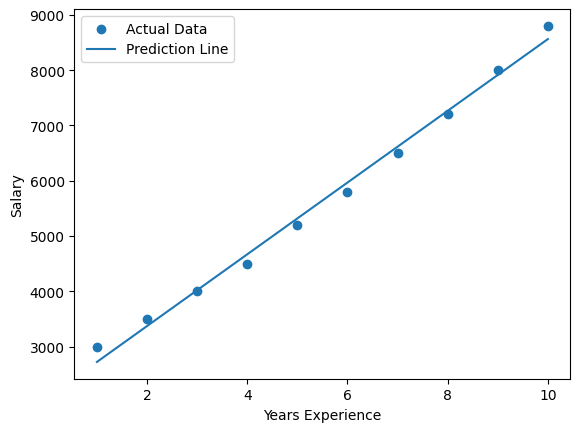

In [61]:
# 8. 그래프 확인

# 실제 데이터 산점도
plt.scatter(X.numpy(), y.numpy(), label='Actual Data')
# 예측 데이터 선형회귀 직선
plt.plot(X.numpy(), pred.numpy(), label='Prediction Line')
plt.xlabel('Years Experience')
plt.ylabel('Salary')
# 그래프 범례 표시
plt.legend()
plt.show()